<a href="https://colab.research.google.com/github/apester/TDA/blob/main/TDA_Lecture_2_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 2 — Core Concepts of Topological Data Analysis

This notebook accompanies **Lecture 2: Core Concepts of TDA** and turns the slide deck into a guided, hands-on notebook.

## Learning goals
- Move from raw data to a metric space
- Build a simplicial complex from a point cloud
- Understand filtrations and scale
- Interpret homology and Betti numbers
- Read persistence summaries conceptually

This notebook is designed to run even without special TDA libraries. Where a library such as `ripser` is available, an optional section uses it.


## 1. Why topology and not only clustering?

A noisy circle is not just “one cloud of points.”  
Its **hole** is part of the structure.

Classical summaries often tell us:
- how many groups there are,
- how spread-out the data is,
- or which directions explain variance.

TDA asks different questions:
- How many connected components are there?
- Is there a loop?
- Does a cavity appear?
- Which of these features survive across scales?


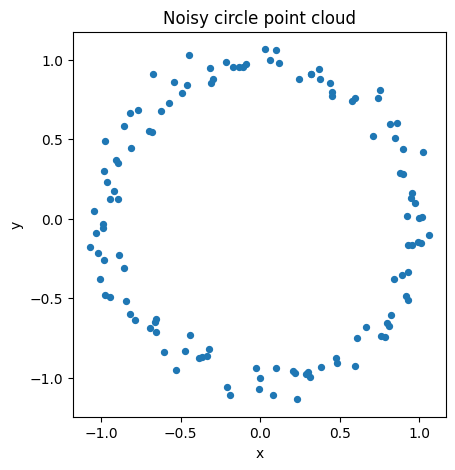

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import hypot

rng = np.random.default_rng(7)

def make_noisy_circle(n=120, radius=1.0, noise=0.07, seed=7):
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = radius * np.cos(theta) + rng.normal(0, noise, n)
    y = radius * np.sin(theta) + rng.normal(0, noise, n)
    return np.column_stack([x, y])

X = make_noisy_circle()
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], s=18)
plt.gca().set_aspect('equal')
plt.title("Noisy circle point cloud")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 2. The TDA pipeline

A typical pipeline is:

1. **Represent data as a metric space**  
   We need a notion of distance or similarity.

2. **Build a simplicial complex**  
   Vertices, edges, triangles, and higher-dimensional simplices are added based on proximity.

3. **Sweep across scales**  
   Instead of picking one value of \(\varepsilon\), we form a nested sequence of complexes.

4. **Compute topological summaries**  
   Typical outputs include connected components, loops, and persistence summaries.


## 3. From raw data to a metric space

The metric determines what “near” means.

Common choices:
- Euclidean distance for continuous vectors
- Cosine distance for embeddings
- Graph shortest-path distance for network data

Below is a small helper to compute a pairwise distance matrix.


In [2]:
def pairwise_distances(X):
    X = np.asarray(X)
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(X[i] - X[j])
            D[i, j] = D[j, i] = d
    return D

X_small = X[:12]
D_small = pairwise_distances(X_small)
np.round(D_small[:5, :5], 3)


array([[0.   , 0.02 , 0.093, 0.075, 0.134],
       [0.02 , 0.   , 0.096, 0.094, 0.139],
       [0.093, 0.096, 0.   , 0.094, 0.044],
       [0.075, 0.094, 0.094, 0.   , 0.114],
       [0.134, 0.139, 0.044, 0.114, 0.   ]])

## 4. Vietoris–Rips intuition

For a scale parameter \(\varepsilon\):

- every data point becomes a **vertex**,
- add an **edge** if the distance between two points is at most \(\varepsilon\),
- fill a **triangle** when all three edges are present,
- continue similarly in higher dimensions.

In practice, Rips complexes are popular because they are easy to define from pairwise distances.


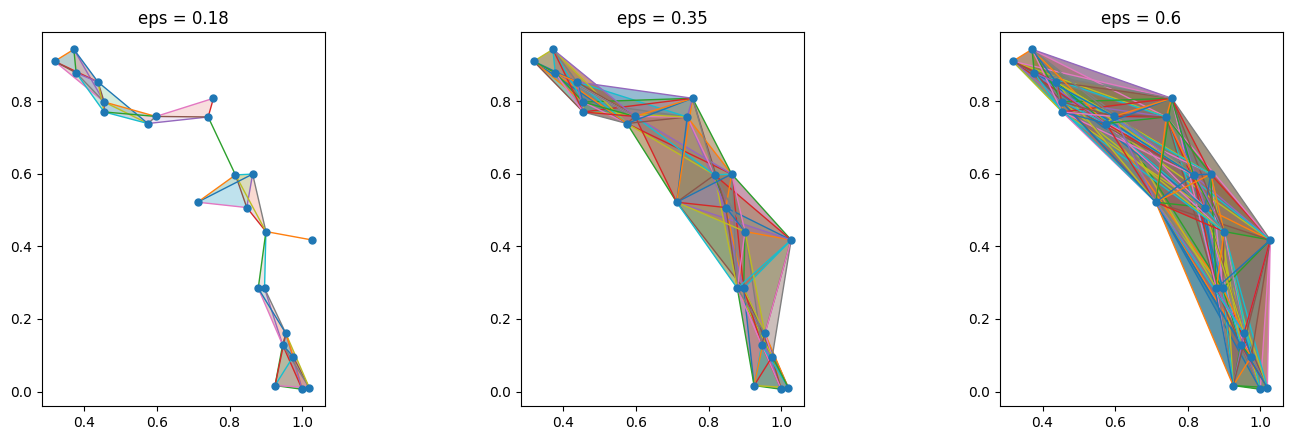

In [3]:
from itertools import combinations

def rips_edges(X, eps):
    D = pairwise_distances(X)
    edges = []
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            if D[i, j] <= eps:
                edges.append((i, j))
    return edges

def rips_triangles(X, eps):
    edges = set(tuple(sorted(e)) for e in rips_edges(X, eps))
    triangles = []
    for i, j, k in combinations(range(len(X)), 3):
        if ((i, j) in edges) and ((i, k) in edges) and ((j, k) in edges):
            triangles.append((i, j, k))
    return triangles

def plot_rips_2d(X, eps, show_triangles=False, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(X[:,0], X[:,1], s=25, zorder=3)
    for i, j in rips_edges(X, eps):
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], lw=1, zorder=2)
    if show_triangles:
        for i, j, k in rips_triangles(X, eps):
            tri = np.array([X[i], X[j], X[k]])
            ax.fill(tri[:,0], tri[:,1], alpha=0.15, zorder=1)
    ax.set_aspect('equal')
    ax.set_title(title or f"Rips complex at eps={eps:.2f}")
    return ax

X_demo = X[:24]
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, eps in zip(axs, [0.18, 0.35, 0.60]):
    plot_rips_2d(X_demo, eps=eps, show_triangles=True, ax=ax, title=f"eps = {eps}")
plt.tight_layout()
plt.show()


## 5. Filtration

A **filtration** is a nested sequence

$[
K_0 \subseteq K_1 \subseteq K_2 \subseteq \dots
]$

where each new complex is built at a larger scale.

Why this matters:
- very small $( \varepsilon )$: many isolated components,
- medium $( \varepsilon )$: meaningful loops can appear,
- large $( \varepsilon )$: loops get filled in and the space becomes topologically simple again.


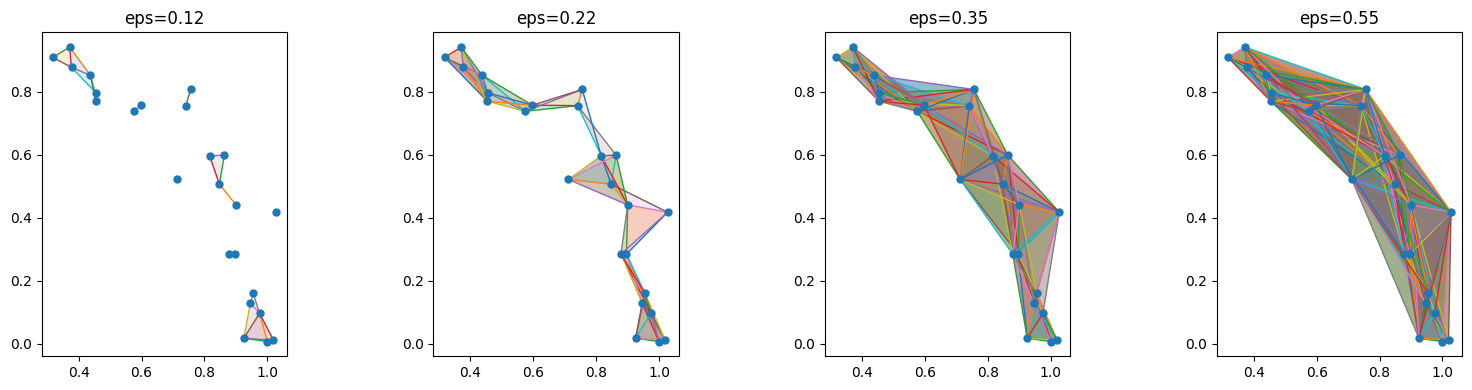

In [4]:
eps_values = [0.12, 0.22, 0.35, 0.55]
fig, axs = plt.subplots(1, len(eps_values), figsize=(16, 4))
for ax, eps in zip(axs, eps_values):
    plot_rips_2d(X_demo, eps=eps, show_triangles=True, ax=ax, title=f"eps={eps}")
plt.tight_layout()
plt.show()


## 6. Homology and Betti numbers

Informally:

- **H₀** tracks connected components  
- **H₁** tracks one-dimensional loops  
- **H₂** tracks two-dimensional cavities  

The associated Betti numbers count these features:

- $(\beta_0)$: number of connected components
- $(\beta_1)$: number of loops
- $(\beta_2)$: number of cavities

Examples:
- a filled disk: $(\beta_0=1, \beta_1=0)$
- a circle: $(\beta_0=1, \beta_1=1)$
- two separate circles: $(\beta_0=2, \beta_1=2)$


## 7. Very light algebraic intuition

Homology is built from a few ingredients:

- **Chains**: formal sums of simplices
- **Boundary operator** \(\partial\): sends a simplex to its faces
- **Cycles**: objects with zero boundary
- **Boundaries**: objects that are themselves boundaries of higher-dimensional objects

Key idea:

A loop counts as a topological feature only when it is a **cycle that is not the boundary** of something already filled in.


In [5]:
# Tiny example: the boundary of a triangle consists of its three edges.
triangle_vertices = ["v0", "v1", "v2"]
triangle_edges = [("v0","v1"), ("v1","v2"), ("v0","v2")]
print("2-simplex:", triangle_vertices)
print("Boundary of the triangle:", triangle_edges)
print("If the triangle is filled, its edge-loop is a boundary, so it does NOT count as a 1-dimensional hole.")


2-simplex: ['v0', 'v1', 'v2']
Boundary of the triangle: [('v0', 'v1'), ('v1', 'v2'), ('v0', 'v2')]
If the triangle is filled, its edge-loop is a boundary, so it does NOT count as a 1-dimensional hole.


## 8. A simple graph-based approximation of $(\beta_0)$

Without using a full TDA library, we can still compute the number of connected components of the Rips graph at each scale.  
This gives intuition for how **H₀** behaves across a filtration.


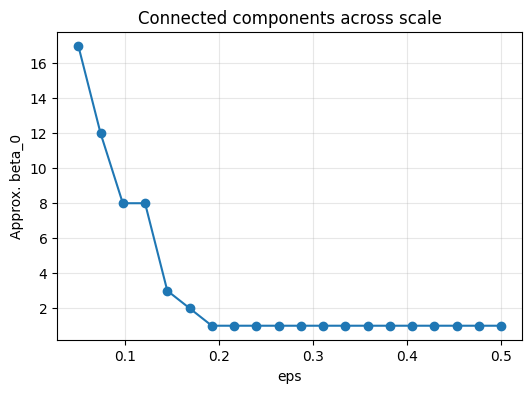

In [6]:
def components_from_edges(n, edges):
    parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in edges:
        union(a, b)
    roots = {find(i) for i in range(n)}
    return len(roots)

eps_grid = np.linspace(0.05, 0.5, 20)
beta0 = [components_from_edges(len(X_demo), rips_edges(X_demo, eps)) for eps in eps_grid]

plt.figure(figsize=(6,4))
plt.plot(eps_grid, beta0, marker="o")
plt.xlabel("eps")
plt.ylabel("Approx. beta_0")
plt.title("Connected components across scale")
plt.grid(True, alpha=0.3)
plt.show()


## 9. Persistent homology

Persistent homology tracks:

- **birth**: when a feature appears,
- **death**: when it disappears,
- **persistence**: death minus birth.

Interpretation:
- long-lived features often suggest robust structure,
- short-lived features are often noise or sampling artifacts,
- but interpretation always depends on the domain and data quality.


## 10. Barcode and persistence diagram

Two common views:

### Barcode
Each feature is shown as a horizontal interval from birth to death.

### Persistence diagram
Each feature becomes a point \((birth, death)\).  
Features farther from the diagonal have greater persistence.


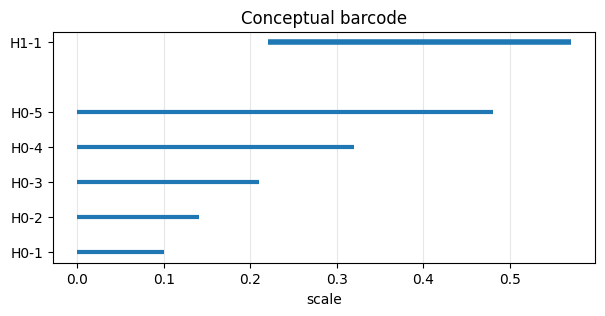

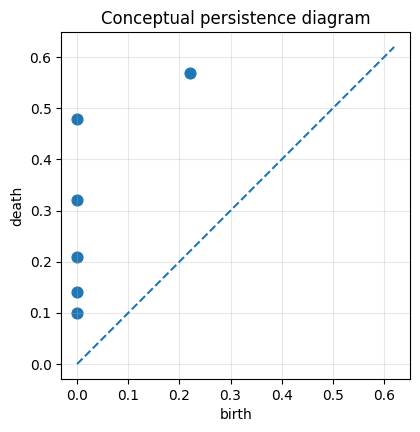

In [7]:
# A conceptual, hand-crafted persistence example for teaching.
bars_h0 = [(0.00, 0.10), (0.00, 0.14), (0.00, 0.21), (0.00, 0.32), (0.00, 0.48)]
bars_h1 = [(0.22, 0.57)]

fig, ax = plt.subplots(figsize=(7, 3))
for i, (b, d) in enumerate(bars_h0):
    ax.hlines(i, b, d, linewidth=3)
offset = len(bars_h0) + 1
for i, (b, d) in enumerate(bars_h1):
    ax.hlines(offset + i, b, d, linewidth=4)

ax.set_yticks(list(range(len(bars_h0))) + [offset])
ax.set_yticklabels([f"H0-{i+1}" for i in range(len(bars_h0))] + ["H1-1"])
ax.set_xlabel("scale")
ax.set_title("Conceptual barcode")
ax.grid(True, axis='x', alpha=0.3)
plt.show()

pts = np.array(bars_h0 + bars_h1)
plt.figure(figsize=(4.5, 4.5))
plt.scatter(pts[:,0], pts[:,1], s=60)
m = max(pts[:,1]) + 0.05
plt.plot([0, m], [0, m], "--")
plt.xlabel("birth")
plt.ylabel("death")
plt.title("Conceptual persistence diagram")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()


## 11. Worked example: noisy circle

For a noisy circle, we usually expect:

- at very small scale: many separate connected components,
- at medium scale: one prominent loop,
- at larger scale: the loop gets filled in and disappears.

That pattern is one of the classic motivations for TDA.


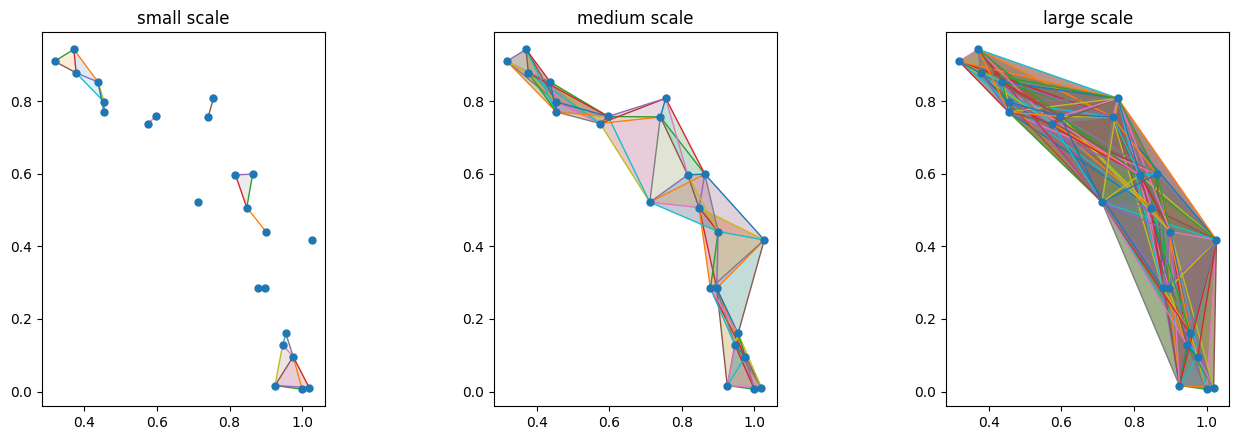

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, eps, label in zip(
    axs,
    [0.12, 0.27, 0.55],
    ["small scale", "medium scale", "large scale"]
):
    plot_rips_2d(X_demo, eps=eps, show_triangles=True, ax=ax, title=label)
plt.tight_layout()
plt.show()


## 12. Optional: compute persistence with `ripser`

If `ripser` is installed, the following cell computes persistent homology directly from the point cloud.  
If it is not installed, the notebook still remains useful.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.8 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=178bf8c00c00d3c6563d78eddc7ca5dded7ed577843ffd4366f1f84f89c7fe28
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp
Persistence computed successfully.
H0 diagram shape: (120, 2)
H1 diagram shape: (5, 2)


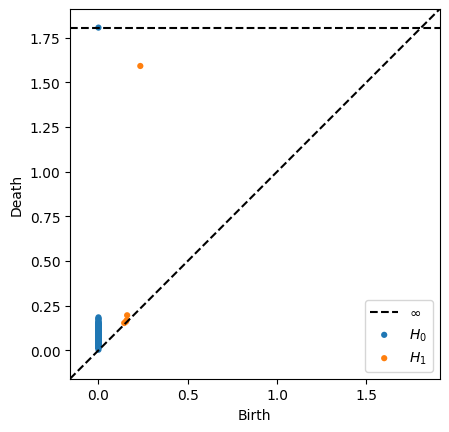

In [9]:
!pip install Cython
!pip install Ripser
try:
    from ripser import ripser
    from persim import plot_diagrams

    result = ripser(X, maxdim=1)
    diagrams = result["dgms"]

    print("Persistence computed successfully.")
    for dim, dgm in enumerate(diagrams):
        print(f"H{dim} diagram shape:", dgm.shape)

    plot_diagrams(diagrams, show=True)
except Exception as e:
    print("Optional section skipped.")
    print("Reason:", e)


## 13. Limitations and good practice

TDA is powerful, but not magic.

Limitations:
- complexes can become huge for large datasets,
- the choice of metric matters,
- the filtration choice matters,
- interpretation improves when combined with domain knowledge.

Good practice:
- compare multiple metrics or preprocessing choices,
- use persistence as one summary among several,
- relate topological features back to the application domain.


## 14. Quick questions

1. What do you expect for \(\beta_0\) when \(\varepsilon\) is extremely small?  
2. Why does a filled triangle not count as a 1-dimensional hole?  
3. In a persistence diagram, what do points near the diagonal typically mean?  
4. Why is it risky to choose only one scale and ignore the filtration?


## 15. Takeaway

TDA does not try to find one perfect geometric reconstruction.  
Instead, it asks:

> **Which topological features persist as scale changes?**

That is the core idea connecting point clouds, simplicial complexes, homology, and persistence.
